Number of steps: 3725
Final t: 4.075169897085259
Final y: -3.162277627097918


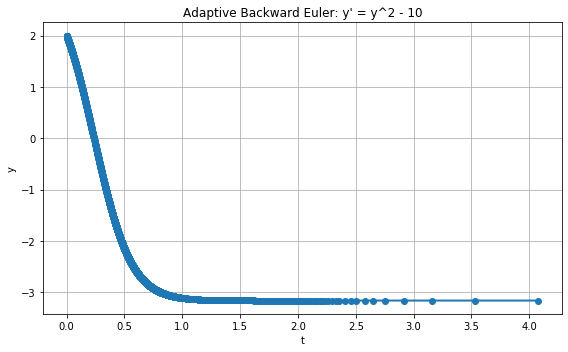

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return y**2 - 10

def fprime(y):
    return 2 * y

def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y

    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)

        if abs(g_prime_val) < 1e-12:
            break

        y_new = y_next - g_val / g_prime_val

        if abs(y_new - y_next) < tol:
            return y_new

        y_next = y_new

    return y_next

def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):

    t_values = [t0]
    y_values = [y0]

    h = h_init
    t = t0
    y = y0

    max_steps = 100000 

    step_count = 0

    while t < tf and step_count < max_steps:

        step_count += 1

        if t + h > tf:
            h = tf - t

        y_full = backward_euler_step(f, y, t, h, tol, max_iter)

        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)

        error = abs(y_full - y_half_2)

        if error > tol:
            h *= 0.5
            continue

        if error < tol / 10:
            h *= 1.5 
        t += h
        y = y_half_2

        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

y0 = 2
t0 = 0
tf = 4
h_init = 0.2

t_vals, y_vals = backward_euler_adaptive(f, y0, t0, tf, h_init)

print("Number of steps:", len(t_vals))
print("Final t:", t_vals[-1])
print("Final y:", y_vals[-1])

plt.figure(figsize=(8, 5))
plt.plot(t_vals, y_vals, marker='o', linewidth=2)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Adaptive Backward Euler: y' = y^2 - 10")
plt.grid(True)
plt.tight_layout()

plt.show()